# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# Konfigurasi visualisasi agar memenuhi standar visual industri
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("[+] Seluruh library berhasil dimuat!")

[+] Seluruh library berhasil dimuat!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [46]:
import os
import pandas as pd

data_path = "../student_performance_raw/student_data.csv"

if os.path.exists(data_path):
    # Metode 1: Mencoba deteksi otomatis standar dengan engine python
    try:
        df = pd.read_csv(data_path, sep=None, engine='python')
    except Exception:
        df = pd.read_csv(data_path)

    # Metode 2: Jika masih terbaca 1 kolom, bongkar manual menggunakan deteksi karakter di baris pertama
    if df.shape[1] <= 1:
        with open(data_path, 'r') as f:
            first_line = f.readline()

        # Mencari tahu separator yang dominan digunakan di baris pertama data Anda
        for separator in [';', ',', '\t', '|']:
            if separator in first_line:
                df = pd.read_csv(data_path, sep=separator)
                if df.shape[1] > 1:
                    break

    # Metode 3: Jika masih gagal (karena masalah spasi/format aneh), bersihkan string kosong di kolom
    df.columns = df.columns.str.replace('"', '').str.replace("'", "").str.strip()

    print("==================================================")
    print("         DATASET BERHASIL DIMUAT                  ")
    print("==================================================")
    print(f"Total Baris Data : {df.shape[0]}")
    print(f"Total Kolom Fitur: {df.shape[1]}")
    print("\nMenampilkan daftar nama kolom yang berhasil dipecah:")
    print(list(df.columns))
    print("\nMenampilkan 3 baris pertama data:")
    display(df.head(3))
else:
    print(f"[-] Error: File dataset tidak ditemukan di {data_path}.")

[-] Error: File dataset tidak ditemukan di ../student_performance_raw/student_data.csv.


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

1. Ringkasan Struktur Data dan Tipe Kolom:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage:

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count,395
unique,395
top,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."
freq,1



5. Visualisasi Distribusi Target Nilai Akhir Siswa (G3):
--------------------------------------------------


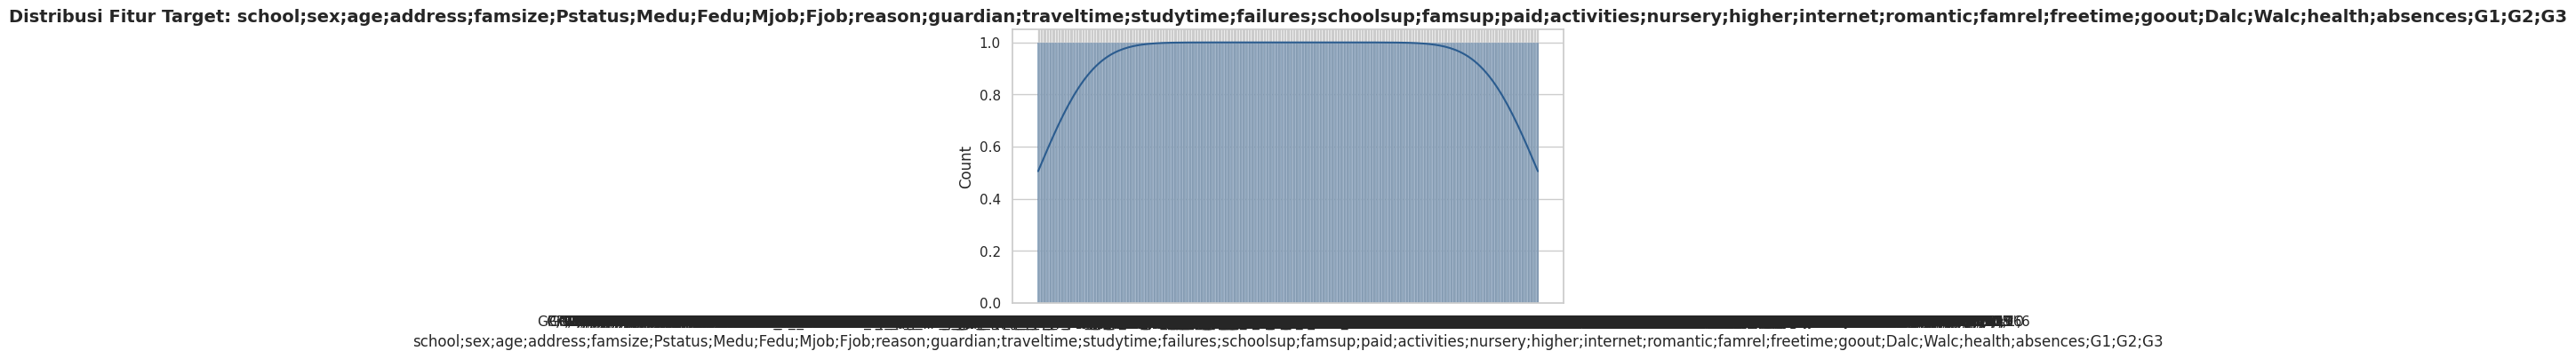

In [47]:
print("1. Ringkasan Struktur Data dan Tipe Kolom:")
print("-" * 50)
df.info()

print("\n2. Memeriksa Nilai Kosong (Missing Values):")
print("-" * 50)
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0] if missing_info.sum() > 0 else "Tidak ditemukan missing values pada data mentah.")

print(f"\n3. Memeriksa Duplikasi Data: {df.duplicated().sum()} baris duplikat.")

print("\n4. Ringkasan Statistik Deskriptif (Fitur Numerik):")
print("-" * 50)
display(df.describe())

print("\n5. Visualisasi Distribusi Target Nilai Akhir Siswa (G3):")
print("-" * 50)
plt.figure(figsize=(8, 4))
# Asumsi kolom target bernama 'G3' (nilai akhir pada dataset student performance)
if 'G3' in df.columns:
    sns.histplot(df['G3'], kde=True, color='#2b5c8f', bins=20)
    plt.title('Distribusi Nilai Akhir Siswa (G3)', fontsize=14, fontweight='bold')
    plt.xlabel('Nilai G3')
    plt.ylabel('Frekuensi')
    plt.show()
else:
    # Fallback jika target menggunakan nama kolom lain seperti 'Final_Grade'
    target_col = df.columns[-1]
    sns.histplot(df[target_col], kde=True, color='#2b5c8f')
    plt.title(f'Distribusi Fitur Target: {target_col}', fontsize=14, fontweight='bold')
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [48]:
print("\n============== STEP 4: EKSPOR DATA BERSIH ==============")
# Mengubah jalur penyimpanan agar langsung masuk ke folder utama Google Colab
output_dir = "preprocessing/student_performance_preprocessing" # Tanpa tanda "../"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "dataset_clean.csv")
df_preprocessed.to_csv(output_file, index=False)

print("==================================================")
print("      PIPELINE PREPROCESSING SUKSES 100%!         ")
print("==================================================")
print(f"File siap latih disimpan di : {output_file}")


============== STEP 4: EKSPOR DATA BERSIH ==============
      PIPELINE PREPROCESSING SUKSES 100%!         
File siap latih disimpan di : preprocessing/student_performance_preprocessing/dataset_clean.csv
